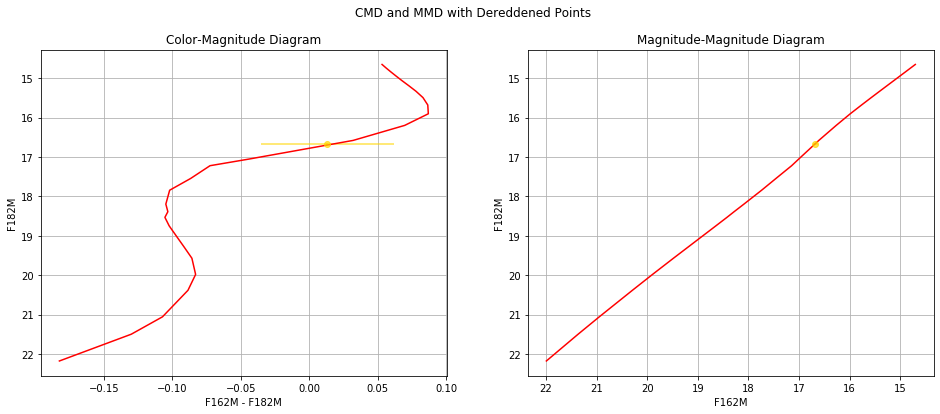

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening
from spisea.imf import imf, multiplicity
from matplotlib.colors import LogNorm
import csv
from scipy.stats import chi2
import heapq

# Paths for isochrones and output
iso_dir = 'isochrones/'
output_dir = 'output_diagrams/'
os.makedirs(output_dir, exist_ok=True)

# Estimation variables
star_index = 0  # Set which star in the CSV to analyze

# Define static isochrone parameters
dist = 4500  # Distance in parsecs
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawCardelli(3.1)
filt_list = ['jwst,F162M', 'jwst,F182M', 'jwst,F200W']
filters = ['m_jwst_F162M', 'm_jwst_F182M', 'm_jwst_F200W']
metallicity = 0
# level_ages = np.linspace(1, 10, 19) * 1e6  # Define age array
level_ages = [1e6]
log_age_arr = np.log10(level_ages)

# Load sample magnitudes and errors from CSV
sample_mags = []
sample_errs = []
with open('/scratch/wyz5rge/synthetic-hr/notebooks/2025/01-28_chi-square-reverse-modeling/s284.csv', mode='r') as file:
    csvFile = csv.reader(file)
    next(csvFile)  # Skip header row
    for lines in csvFile:
        mags = [float(lines[i]) for i in range(1, len(lines), 2)]
        errs = [float(lines[i]) for i in range(2, len(lines), 2)]
        sample_mags.append(mags)
        sample_errs.append(errs)

# Function to generate isochrone grid
def generate_isochrones(AKs):
    return np.array([
        synthetic.IsochronePhot(log_age, AKs, dist, metallicity=metallicity,
                                evo_model=evo_model, atm_func=atm_func,
                                red_law=red_law, filters=filt_list,
                                iso_dir=iso_dir)
        for log_age in log_age_arr
    ])

# Generate isochrone grid for AKs = 0 (no extinction)
isochrone_AKs_00 = generate_isochrones(0.0)

# Wavelength dictionary for JWST filters
filter_wavelengths = {
    "m_jwst_F162M": 1.62,
    "m_jwst_F182M": 1.82,
    "m_jwst_F200W": 2.00,
    "m_jwst_F356M": 3.56,
    "m_jwst_F405N": 4.05
}

# Extract magnitudes and errors for the selected star
m162, m182 = sample_mags[star_index][:2]  # Magnitudes
err162, err182 = sample_errs[star_index][:2]  # Errors

# Define AKs range for dereddening
# AKs_values = np.arange(0.8, 0.95, 0.01)  # Adjustable range and step size
AKs_values = [0.88]

# Store dereddened magnitudes
dereddened_mags = []
for AKs_ref in AKs_values:
    m162_dered = m162 - red_law.Cardelli89(filter_wavelengths["m_jwst_F162M"], AKs_ref)
    m182_dered = m182 - red_law.Cardelli89(filter_wavelengths["m_jwst_F182M"], AKs_ref)
    dereddened_mags.append((m162_dered, m182_dered))

# Compute errors in color (m162 - m182) and in F182M magnitude
color_err = np.sqrt(err162**2 + err182**2)  # Propagate errors in color
mag_err = err182  # Vertical error is just the F182M error

# Plot function with dereddened points
def plot_cmd_mmd_with_dereddening(isochrone_grid, dered_mags, ref_errs, title, filename):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    cmap = plt.get_cmap("coolwarm")

    # Plot Color-Magnitude Diagram (CMD)
    for i, instance in enumerate(isochrone_grid):
        # color = cmap(i / (len(isochrone_grid) - 1))
        # ax1.plot(instance.points["m_jwst_F162M"] - instance.points["m_jwst_F182M"],
        #          instance.points["m_jwst_F182M"], color=color)
        ax1.plot(instance.points["m_jwst_F162M"] - instance.points["m_jwst_F182M"],
                 instance.points["m_jwst_F182M"], color="r")
    
    for i, (m162_d, m182_d) in enumerate(dered_mags):
        ax1.errorbar(m162_d - m182_d, m182_d, xerr=ref_errs[0], yerr=ref_errs[1],
                     fmt='o', color='gold', alpha=0.7)
    
    ax1.set_xlabel("F162M - F182M")
    ax1.set_ylabel("F182M")
    ax1.invert_yaxis()
    ax1.grid(True)
    ax1.set_title("Color-Magnitude Diagram")

    # Plot Magnitude-Magnitude Diagram (MMD)
    for i, instance in enumerate(isochrone_grid):
        # color = cmap(i / (len(isochrone_grid) - 1))
        # ax2.plot(instance.points["m_jwst_F162M"], instance.points["m_jwst_F182M"], color=color)
        ax2.plot(instance.points["m_jwst_F162M"], instance.points["m_jwst_F182M"], color="r")
    
    for i, (m162_d, m182_d) in enumerate(dered_mags):
        ax2.errorbar(m162_d, m182_d, xerr=ref_errs[0], yerr=ref_errs[1],
                     fmt='o', color='gold', alpha=0.7)
    
    ax2.set_xlabel("F162M")
    ax2.set_ylabel("F182M")
    ax2.invert_xaxis()
    ax2.invert_yaxis()
    ax2.grid(True)
    ax2.set_title("Magnitude-Magnitude Diagram")

    plt.suptitle(title)
    # plt.savefig(os.path.join(output_dir, filename))
    plt.show()

# Plot CMD and MMD with dereddened points
plot_cmd_mmd_with_dereddening(isochrone_AKs_00, dereddened_mags, [color_err, mag_err],
                              "CMD and MMD with Dereddened Points", "CMD_MMD_DEREDDENED.png")


In [9]:
# iso_instance is an element of the isochrone grid (for your single log_age=6.00, it is isochrone_AKs_00[0])
iso_instance = isochrone_AKs_00[0]

print("Mass vs Magnitude for each filter:")
for filt in filters:
    print(f"\nFilter: {filt}")
    masses = iso_instance.points["mass"]  # Mass array
    mags = iso_instance.points[filt]      # Magnitude array for this filter
    
    for m, mag in zip(masses, mags):
        print(f"Mass: {m:.4f} Msun, Magnitude: {mag:.4f}")

Mass vs Magnitude for each filter:

Filter: m_jwst_F162M
Mass: 0.0100 Msun, Magnitude: 21.9939
Mass: 0.0150 Msun, Magnitude: 21.3667
Mass: 0.0200 Msun, Magnitude: 20.9481
Mass: 0.0300 Msun, Magnitude: 20.2937
Mass: 0.0400 Msun, Magnitude: 19.8967
Mass: 0.0500 Msun, Magnitude: 19.4826
Mass: 0.0600 Msun, Magnitude: 19.1861
Mass: 0.0700 Msun, Magnitude: 18.9026
Mass: 0.0720 Msun, Magnitude: 18.8438
Mass: 0.0750 Msun, Magnitude: 18.7687
Mass: 0.0800 Msun, Magnitude: 18.6424
Mass: 0.0900 Msun, Magnitude: 18.4251
Mass: 0.1000 Msun, Magnitude: 18.2838
Mass: 0.1100 Msun, Magnitude: 18.0892
Mass: 0.1300 Msun, Magnitude: 17.7394
Mass: 0.1500 Msun, Magnitude: 17.4567
Mass: 0.1700 Msun, Magnitude: 17.1464
Mass: 0.2000 Msun, Magnitude: 17.0073
Mass: 0.3000 Msun, Magnitude: 16.6091
Mass: 0.4000 Msun, Magnitude: 16.2655
Mass: 0.5000 Msun, Magnitude: 15.9875
Mass: 0.6000 Msun, Magnitude: 15.7647
Mass: 0.7000 Msun, Magnitude: 15.5730
Mass: 0.8000 Msun, Magnitude: 15.4074
Mass: 0.9000 Msun, Magnitude: 1

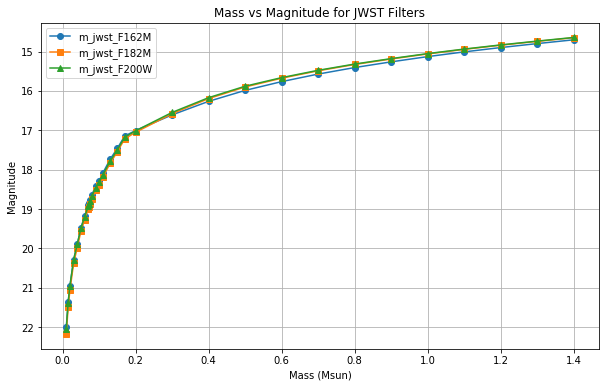

In [10]:
import matplotlib.pyplot as plt

# Data from your message (mass in Msun, magnitude)
mass = [0.0100, 0.0150, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0720,
        0.0750, 0.0800, 0.0900, 0.1000, 0.1100, 0.1300, 0.1500, 0.1700, 0.2000,
        0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000, 0.9000, 1.0000, 1.1000,
        1.2000, 1.3000, 1.4000]

mag_F162M = [21.9939, 21.3667, 20.9481, 20.2937, 19.8967, 19.4826, 19.1861, 18.9026,
             18.8438, 18.7687, 18.6424, 18.4251, 18.2838, 18.0892, 17.7394, 17.4567,
             17.1464, 17.0073, 16.6091, 16.2655, 15.9875, 15.7647, 15.5730, 15.4074,
             15.2626, 15.1292, 15.0092, 14.8993, 14.7987, 14.7022]

mag_F182M = [22.1764, 21.4967, 21.0554, 20.3823, 19.9797, 19.5684, 19.2777, 18.9998,
             18.9422, 18.8686, 18.7448, 18.5306, 18.3871, 18.1939, 17.8414, 17.5434,
             17.2189, 17.0514, 16.5770, 16.1957, 15.9005, 15.6781, 15.4899, 15.3293,
             15.1897, 15.0614, 14.9457, 14.8396, 14.7423, 14.6489]

mag_F200W = [22.0386, 21.3812, 20.9516, 20.2924, 19.8980, 19.4922, 19.2065, 18.9325,
             18.8750, 18.8019, 18.6788, 18.4665, 18.3261, 18.1356, 17.7893, 17.4963,
             17.1772, 17.0134, 16.5466, 16.1721, 15.8814, 15.6630, 15.4772, 15.3184,
             15.1801, 15.0527, 14.9378, 14.8323, 14.7356, 14.6427]

plt.figure(figsize=(10, 6))
plt.plot(mass, mag_F162M, marker='o', label='m_jwst_F162M')
plt.plot(mass, mag_F182M, marker='s', label='m_jwst_F182M')
plt.plot(mass, mag_F200W, marker='^', label='m_jwst_F200W')

plt.gca().invert_yaxis()  # Magnitude: brighter stars are lower numbers
plt.xlabel('Mass (Msun)')
plt.ylabel('Magnitude')
plt.title('Mass vs Magnitude for JWST Filters')
plt.legend()
plt.grid(True)
plt.show()

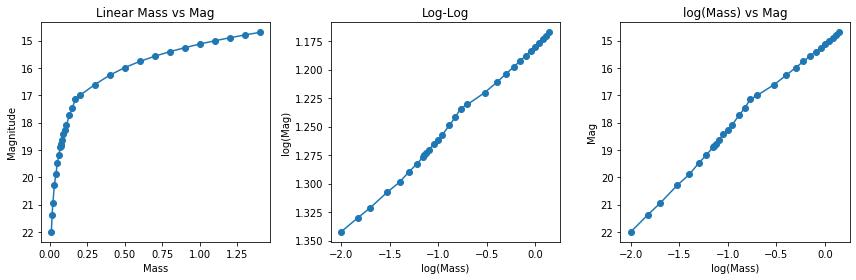

In [13]:
plt.figure(figsize=(12, 4))

# Linear plot
plt.subplot(1, 3, 1)
plt.plot(mass, mag_F162M, 'o-')
plt.title('Linear Mass vs Mag')
plt.xlabel('Mass')
plt.ylabel('Magnitude')
plt.gca().invert_yaxis()

# Log-log plot
plt.subplot(1, 3, 2)
plt.plot(np.log10(mass), np.log10(mag_F162M), 'o-')
plt.title('Log-Log')
plt.xlabel('log(Mass)')
plt.ylabel('log(Mag)')
plt.gca().invert_yaxis()

# Semi-log
plt.subplot(1, 3, 3)
plt.plot(np.log10(mass), mag_F162M, 'o-')
plt.title('log(Mass) vs Mag')
plt.xlabel('log(Mass)')
plt.ylabel('Mag')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()